In [1]:
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/mine_new_dataset_encrypted/new_dataset_encrypted' /content

In [2]:
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed' /content

In [3]:
import os

root = "/content/new_dataset_encrypted"
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

total = 0

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path):
        n = sum(
            1 for f in os.listdir(cls_path)
            if f.lower().endswith(valid_exts)
        )
        print(f"{cls}: {n}")
        total += n

print("Tổng:", total)

PNEUMONIA: 1800
COVID: 1626
NORMAL: 1802
Tổng: 5228


In [4]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

root = "/content/new_dataset_encrypted"
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

classes = sorted([
    cls for cls in os.listdir(root)
    if os.path.isdir(os.path.join(root, cls))
])

num_rows = len(classes)
num_cols = 5

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))

if num_rows == 1:
    axes = [axes]

for i, cls in enumerate(classes):
    cls_path = os.path.join(root, cls)

    imgs = [
        os.path.join(cls_path, f)
        for f in os.listdir(cls_path)
        if f.lower().endswith(valid_exts)
    ]

    chosen = random.sample(imgs, min(num_cols, len(imgs)))

    for j in range(num_cols):
        ax = axes[i][j] if num_rows > 1 else axes[j]

        if j < len(chosen):
            img = Image.open(chosen[j]).convert("RGB")
            ax.imshow(img)
            ax.set_title(f"{cls}", fontsize=10)
        else:
            ax.imshow([[255]])
            ax.set_title(f"{cls}\n(empty)", fontsize=9)

        ax.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os
import shutil
DATASET_ENCRYPTED_TRAIN  = '/content/data_encrypted'
# DATASET_ENCRYPTED_TEST  = '/content/data_encrypted/test'
ENC_TRAIN = os.path.join(DATASET_ENCRYPTED_TRAIN, "")
for root, dirs, files in os.walk(ENC_TRAIN):
    if ".ipynb_checkpoints" in dirs:
        shutil.rmtree(os.path.join(root, ".ipynb_checkpoints"))
        print("Đã xóa:", os.path.join(root, ".ipynb_checkpoints"))

In [5]:
import torch
from torch.utils.data import DataLoader, Subset
import numpy as np
from tqdm.auto import tqdm

def compute_mean_std(dataset, batch_size=64, num_workers=4, max_samples=2000, seed=42):

    n = len(dataset)
    if max_samples is not None and max_samples < n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=max_samples, replace=False)
        dataset = Subset(dataset, idx.tolist())

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

    channel_sum = torch.zeros(3)
    channel_sumsq = torch.zeros(3)
    pixel_count = 0

    for x, _ in tqdm(loader, desc="Compute mean/std"):
        # x: [B,3,H,W] in [0,1]
        b, c, h, w = x.shape
        x = x.float()

        channel_sum += x.sum(dim=[0,2,3])
        channel_sumsq += (x ** 2).sum(dim=[0,2,3])
        pixel_count += b * h * w

    mean = channel_sum / pixel_count
    var = channel_sumsq / pixel_count - mean**2
    std = torch.sqrt(var.clamp_min(1e-12))

    return mean.tolist(), std.tolist()


In [7]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import numpy as np

ENC_ROOT = "/content/new_dataset_encrypted"

BATCH_SIZE = 128
NUM_WORKERS = 12
SEED = 42


# Load toàn bộ dataset, không cần folder train/test
full_ds = ImageFolder(ENC_ROOT)

targets = np.array(full_ds.targets)
indices = np.arange(len(full_ds))


# Split train / temp
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=targets,
    random_state=SEED
)

# Split temp thành val / test
temp_targets = targets[temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_targets,
    random_state=SEED
)


print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))


# Transform chỉ để tính mean/std
tf_stats = transforms.Compose([
    transforms.ToTensor(),
])

stats_ds_full = ImageFolder(
    ENC_ROOT,
    transform=tf_stats
)

train_stats_ds = Subset(stats_ds_full, train_idx)


mean_enc, std_enc = compute_mean_std(
    train_stats_ds,
    batch_size=BATCH_SIZE,
    max_samples=None
)

print("mean_enc:", mean_enc)
print("std_enc :", std_enc)

Train: 3659
Val: 784
Test: 785


Compute mean/std:   0%|          | 0/29 [00:00<?, ?it/s]

mean_enc: [0.1265062838792801, 0.1264939159154892, 0.12679000198841095]
std_enc : [0.1912969946861267, 0.19120179116725922, 0.19160065054893494]


In [9]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import numpy as np

# ENC_ROOT = "/content/data_encrypted"
# train_idx, val_idx, test_idx đã có từ bước split
# mean_enc, std_enc đã tính từ train_stats_ds


# =========================
# 3) Transform
# =========================
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])


train_enc_ds_full = ImageFolder(ENC_ROOT, transform=train_tf)
eval_enc_ds_full  = ImageFolder(ENC_ROOT, transform=eval_tf)

train_enc_ds = Subset(train_enc_ds_full, train_idx)
val_enc_ds   = Subset(eval_enc_ds_full, val_idx)
test_enc_ds  = Subset(eval_enc_ds_full, test_idx)


train_enc_loader = DataLoader(
    train_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True
)

val_enc_loader = DataLoader(
    val_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

test_enc_loader = DataLoader(
    test_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)


print("train:", len(train_enc_ds))
print("val  :", len(val_enc_ds))
print("test :", len(test_enc_ds))

print("classes:", train_enc_ds_full.classes)
print("class_to_idx:", train_enc_ds_full.class_to_idx)


# kiểm tra phân bố class từng split
targets = np.array(train_enc_ds_full.targets)

train_targets = targets[train_idx]
val_targets   = targets[val_idx]
test_targets  = targets[test_idx]

print("train class counts:", np.bincount(train_targets))
print("val   class counts:", np.bincount(val_targets))
print("test  class counts:", np.bincount(test_targets))

train: 3659
val  : 784
test : 785
classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
train class counts: [1138 1261 1260]
val   class counts: [244 270 270]
test  class counts: [244 271 270]


In [10]:
import torch.optim as optim
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights, vgg19, VGG19_Weights

import torchvision.models as models

from tqdm.auto import tqdm
NUM_CLASSES = 3


def resnet50(num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=False):
    model = models.resnet50(pretrained=pretrained)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith("fc."):
                p.requires_grad = False
    return model


def vgg19(num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=False):
    model = models.vgg19(pretrained=pretrained)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith("classifier."):
                p.requires_grad = False
    return model


import torch.optim as optim

def make_optimizer(model, lr=1e-4, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    return optim.AdamW(params, lr=lr, weight_decay=weight_decay)


In [11]:
import os, csv

class EarlyStopping:
    def __init__(self, patience=8, mode="min", min_delta=1e-4):

        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best = None
        self.bad = 0

    def step(self, value):
        if self.best is None:
            self.best = value
            return False, True  # stop?, is_best?

        improved = (value < self.best - self.min_delta) if self.mode == "min" else (value > self.best + self.min_delta)

        if improved:
            self.best = value
            self.bad = 0
            return False, True
        else:
            self.bad += 1
            return (self.bad >= self.patience), False

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None, use_mixup=True):
    model.train()
    correct, total, loss_sum = 0, 0, 0.0

    pbar = tqdm(loader, desc="Train", leave=False)

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_mixup:
            x, y_a, y_b, lam = mixup(x, y)

        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                out = model(x)

                if use_mixup:
                    loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                else:
                    loss = criterion(out, y)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

        else:
            out = model(x)

            if use_mixup:
                loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
            else:
                loss = criterion(out, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

        loss_sum += loss.item() * y.size(0)

        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

        pbar.set_postfix(loss=loss.item())

    return loss_sum / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        out = model(x)
        loss = criterion(out, y)

        loss_sum += loss.item() * y.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return loss_sum / max(total, 1), correct / max(total, 1)



In [12]:
import torch
import torch.nn as nn



import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_full(model, loader, device, num_classes=3):
    model.eval()
    all_logits = []
    all_y = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)

        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    logits = torch.cat(all_logits, dim=0)   # (N,C)
    y_true = torch.cat(all_y, dim=0)        # (N,)

    y_pred = logits.argmax(dim=1)

    # --- confusion matrix ---
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    total = cm.sum().item()
    correct = cm.diag().sum().item()
    acc = correct / max(total, 1)

    # --- per-class precision/recall/f1/support ---
    per_class = []
    for c in range(num_classes):
        tp = cm[c, c].item()
        fp = cm[:, c].sum().item() - tp
        fn = cm[c, :].sum().item() - tp
        support = cm[c, :].sum().item()

        precision = tp / max(tp + fp, 1)
        recall    = tp / max(tp + fn, 1)
        f1        = 0.0 if (precision + recall) == 0 else (2 * precision * recall / (precision + recall))

        per_class.append({
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support
        })

    # --- macro averages ---
    macro_precision = sum(d["precision"] for d in per_class) / num_classes
    macro_recall    = sum(d["recall"] for d in per_class) / num_classes
    macro_f1        = sum(d["f1"] for d in per_class) / num_classes

    # --- weighted averages ---
    supports = [d["support"] for d in per_class]
    total_support = max(sum(supports), 1)

    weighted_precision = sum(d["precision"] * d["support"] for d in per_class) / total_support
    weighted_recall    = sum(d["recall"]    * d["support"] for d in per_class) / total_support
    weighted_f1        = sum(d["f1"]        * d["support"] for d in per_class) / total_support

    # --- micro (multi-class single-label: micro P=R=F1=accuracy) ---
    micro_precision = acc
    micro_recall = acc
    micro_f1 = acc

    # --- return dict ---
    return {
        "acc": acc,
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,

        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,

        "per_class": per_class,
        "confusion_matrix": cm,
        "logits": logits,
        "y_true": y_true
    }


def plot_confusion_matrix(cm, class_names=None, normalize=False, figsize=(6, 5)):
    cm = cm.clone().float()

    if normalize:
        row_sums = cm.sum(dim=1, keepdim=True).clamp_min(1)
        cm = cm / row_sums

    num_classes = cm.shape[0]

    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.colorbar()

    tick_marks = range(num_classes)
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max().item() / 2 if cm.numel() > 0 else 0.5

    for i in range(num_classes):
        for j in range(num_classes):
            value = cm[i, j].item()
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            plt.text(
                j, i, text,
                ha="center", va="center",
                color="white" if value > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()
def fit(model, train_loader, val_loader, mixup, device="cuda", epochs=30, lr=3e-4, weight_decay=1e-4,
        use_amp=True, patience=8, csv_path="logs/train_log.csv", best_path="checkpoints/best.pt",
        num_classes=3):

    device = torch.device(device if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Label smoothing
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay
    )

    # Cosine scheduler (better than plateau)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    scaler = torch.amp.GradScaler('cuda') if (use_amp and device.type == "cuda") else None
    es = EarlyStopping(patience=patience, mode="max")

    os.makedirs(os.path.dirname(csv_path) or ".", exist_ok=True)
    os.makedirs(os.path.dirname(best_path) or ".", exist_ok=True)

    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["epoch", "lr", "train_loss", "train_acc", "val_loss", "val_acc", "val_macro_f1", "is_best"])

    for ep in range(1, epochs + 1):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            scaler=scaler, use_mixup=mixup   # bật mixup
        )

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        val_full = evaluate_full(model, val_loader, device, num_classes=num_classes)
        val_macro_f1 = val_full["macro_f1"]

        scheduler.step()
        curr_lr = optimizer.param_groups[0]["lr"]

        should_stop, is_best = es.step(val_macro_f1)

        if is_best:
            torch.save({
                "epoch": ep,
                "model_state": model.state_dict(),
                "best_value": es.best,
            }, best_path)

        with open(csv_path, "a", newline="") as f:
            w = csv.writer(f)
            w.writerow([ep, curr_lr, train_loss, train_acc, val_loss, val_acc, val_macro_f1, int(is_best)])

        print(
            f"Epoch {ep:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} || "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} macroF1 {val_macro_f1:.4f} | lr {curr_lr:.2e}"
            + (" save" if is_best else "")
        )

        if should_stop:
            print(f"Early stopping at epoch {ep} (best macroF1={es.best:.4f})")
            break

    return best_path, csv_path


In [13]:
def mixup(x, y, alpha=0.1):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    index = torch.randperm(x.size(0)).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

In [14]:
import math
device = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 50
LR = 3e-4

model_resnet_enc = resnet50(
    num_classes=3,
    pretrained=True,
    freeze_backbone=False
).to(device)

best_path, csv_path = fit(
    model_resnet_enc,
    train_loader=train_enc_loader,
    val_loader=val_enc_loader,
    mixup = False,
    device=device,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=1e-4,
    patience=10,
    csv_path="logs/resnet50_log.csv",
    best_path="checkpoints/resnet50_best.pt",
    num_classes=3,
    use_amp=True,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 282MB/s]


Train:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.5615 acc 0.7966 || val loss 0.4630 acc 0.8597 macroF1 0.8563 | lr 3.00e-04 save


...

Epoch 26/50 | train loss 0.1714 acc 0.9994 || val loss 0.2878 acc 0.9503 macroF1 0.9510 | lr 1.41e-04


Train:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 27/50 | train loss 0.1710 acc 1.0000 || val loss 0.2809 acc 0.9528 macroF1 0.9536 | lr 1.31e-04


Train:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 28/50 | train loss 0.1718 acc 0.9997 || val loss 0.2863 acc 0.9554 macroF1 0.9561 | lr 1.22e-04
Early stopping at epoch 28 (best macroF1=0.9565)


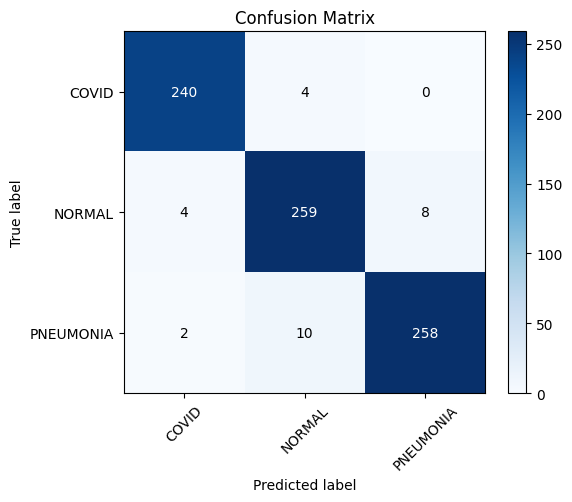

TEST acc         : 0.9643312101910828
TEST macro_f1    : 0.9648280954172713
TEST weighted_f1 : 0.9643230260066761
TEST per_class   : [{'precision': 0.975609756097561, 'recall': 0.9836065573770492, 'f1': 0.9795918367346939, 'support': 244}, {'precision': 0.9487179487179487, 'recall': 0.955719557195572, 'f1': 0.9522058823529412, 'support': 271}, {'precision': 0.9699248120300752, 'recall': 0.9555555555555556, 'f1': 0.9626865671641791, 'support': 270}]


{'acc': 0.9643312101910828,
 'micro_precision': 0.9643312101910828,
 'micro_recall': 0.9643312101910828,
 'micro_f1': 0.9643312101910828,
 'macro_precision': 0.9647508389485283,
 'macro_recall': 0.9649605567093923,
 'macro_f1': 0.9648280954172713,
 'weighted_precision': 0.964370756482152,
 'weighted_recall': 0.9643312101910828,
 'weighted_f1': 0.9643230260066761,
 'per_class': [{'precision': 0.975609756097561,
   'recall': 0.9836065573770492,
   'f1': 0.9795918367346939,
   'support': 244},
  {'precision': 0.9487179487179487,
   'recall': 0.955719557195572,
   'f1': 0.9522058823529412,
   'support': 271},
  {'precision': 0.9699248120300752,
   'recall': 0.9555555555555556,
   'f1': 0.9626865671641791,
   'support': 270}],
 'confusion_matrix': tensor([[240,   4,   0],
         [  4, 259,   8],
         [  2,  10, 258]]),
 'logits': tensor([[-1.7316, -1.5780,  2.3036],
         [-1.4766,  2.0257, -1.3714],
         [-1.6471,  2.5707, -1.8188],
         ...,
         [ 3.0538, -0.9866, -0

In [15]:
# load best model
ckpt = torch.load("checkpoints/resnet50_best.pt", map_location=device)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    model_resnet_enc.load_state_dict(ckpt["model_state"])
else:
    model_resnet_enc.load_state_dict(ckpt)

model_resnet_enc.to(device)
model_resnet_enc.eval()

# evaluate on TEST
test_result = evaluate_full(
    model_resnet_enc,
    test_enc_loader,
    device=device,
    num_classes=3
)

plot_confusion_matrix(
    test_result["confusion_matrix"],
    class_names=train_enc_ds_full.classes,
    normalize=False
)

print("TEST acc         :", test_result["acc"])
print("TEST macro_f1    :", test_result["macro_f1"])
print("TEST weighted_f1 :", test_result["weighted_f1"])
print("TEST per_class   :", test_result["per_class"])

test_result

In [17]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import numpy as np

ORG_ROOT = "/content/new_dataset_processed"

BATCH_SIZE = 64
NUM_WORKERS = 12
SEED = 42


full_org_ds = ImageFolder(ORG_ROOT)

targets_org = np.array(full_org_ds.targets)
indices_org = np.arange(len(full_org_ds))


train_idx_org, temp_idx_org = train_test_split(
    indices_org,
    test_size=0.3,
    stratify=targets_org,
    random_state=SEED
)

temp_targets_org = targets_org[temp_idx_org]

val_idx_org, test_idx_org = train_test_split(
    temp_idx_org,
    test_size=0.5,
    stratify=temp_targets_org,
    random_state=SEED
)


print("Train:", len(train_idx_org))
print("Val:", len(val_idx_org))
print("Test:", len(test_idx_org))


tf_stats = transforms.Compose([
    transforms.ToTensor(),
])

stats_org_ds_full = ImageFolder(
    ORG_ROOT,
    transform=tf_stats
)

train_org_stats_ds = Subset(
    stats_org_ds_full,
    train_idx_org
)


mean_origin, std_origin = compute_mean_std(
    train_org_stats_ds,
    batch_size=BATCH_SIZE,
    max_samples=None
)

print("mean_origin:", mean_origin)
print("std_origin :", std_origin)

Train: 3659
Val: 784
Test: 785


Compute mean/std:   0%|          | 0/58 [00:00<?, ?it/s]

mean_origin: [0.5019229650497437, 0.502015233039856, 0.5021896362304688]
std_origin : [0.23932693898677826, 0.2393261343240738, 0.2393684685230255]


In [22]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import numpy as np

# ORG_ROOT = "/content/data_processed"
# train_idx_org, val_idx_org, test_idx_org đã có
# mean_origin, std_origin đã có


# =========================
# 3) Transform
# =========================
train_tf_origin = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(mean_origin, std_origin),
])

eval_tf_origin = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_origin, std_origin),
])


train_origin_ds_full = ImageFolder(ORG_ROOT, transform=train_tf_origin)
eval_origin_ds_full  = ImageFolder(ORG_ROOT, transform=eval_tf_origin)

train_origin_ds = Subset(train_origin_ds_full, train_idx_org)
val_origin_ds   = Subset(eval_origin_ds_full, val_idx_org)
test_origin_ds  = Subset(eval_origin_ds_full, test_idx_org)


train_origin_loader = DataLoader(
    train_origin_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True
)

val_origin_loader = DataLoader(
    val_origin_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

test_origin_loader = DataLoader(
    test_origin_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)


print("train:", len(train_origin_ds))
print("val  :", len(val_origin_ds))
print("test :", len(test_origin_ds))

print("classes:", train_origin_ds_full.classes)
print("class_to_idx:", train_origin_ds_full.class_to_idx)


# kiểm tra phân bố class từng split
train_targets_org = targets_org[train_idx_org]
val_targets_org   = targets_org[val_idx_org]
test_targets_org  = targets_org[test_idx_org]

print("train class counts:", np.bincount(train_targets_org))
print("val   class counts:", np.bincount(val_targets_org))
print("test  class counts:", np.bincount(test_targets_org))

train: 3659
val  : 784
test : 785
classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
train class counts: [1138 1261 1260]
val   class counts: [244 270 270]
test  class counts: [244 271 270]


In [23]:
import math
device = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 50
LR = 3e-4

model_resnet_origin = resnet50(
    num_classes=3,
    pretrained=True,
    freeze_backbone=False
).to(device)

best_path, csv_path = fit(
    model_resnet_origin,
    train_loader=train_origin_loader,
    val_loader=val_origin_loader,
    device=device,
    epochs=EPOCHS,
    mixup = False,
    lr=LR,
    weight_decay=1e-4,
    patience=5,
    csv_path="logs/resnet50_origin_log.csv",
    best_path="checkpoints/resnet50_origin_best.pt",
    num_classes=3,
    use_amp=True,
)

Train:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.3071 acc 0.9424 || val loss 0.2435 acc 0.9707 macroF1 0.9714 | lr 3.00e-04 save


Train:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 02/50 | train loss 0.2342 acc 0.9748 || val loss 0.2889 acc 0.9490 macroF1 0.9504 | lr 2.99e-04


Train:   0%|          | 0/57 [00:00<?, ?it/s]

...

Epoch 13/50 | train loss 0.1844 acc 0.9956 || val loss 0.2013 acc 0.9847 macroF1 0.9850 | lr 2.53e-04


Train:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 14/50 | train loss 0.1827 acc 0.9970 || val loss 0.1964 acc 0.9847 macroF1 0.9852 | lr 2.46e-04


Train:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 15/50 | train loss 0.1799 acc 0.9964 || val loss 0.1944 acc 0.9885 macroF1 0.9888 | lr 2.38e-04
Early stopping at epoch 15 (best macroF1=0.9938)


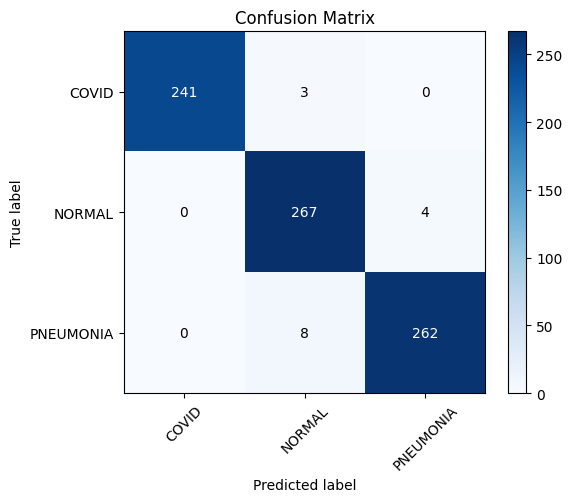

TEST acc         : 0.9808917197452229
TEST macro_f1    : 0.9813679896388711
TEST weighted_f1 : 0.9809446801852001
TEST per_class   : [{'precision': 1.0, 'recall': 0.9877049180327869, 'f1': 0.9938144329896906, 'support': 244}, {'precision': 0.960431654676259, 'recall': 0.985239852398524, 'f1': 0.9726775956284153, 'support': 271}, {'precision': 0.9849624060150376, 'recall': 0.9703703703703703, 'f1': 0.9776119402985074, 'support': 270}]


{'acc': 0.9808917197452229,
 'micro_precision': 0.9808917197452229,
 'micro_recall': 0.9808917197452229,
 'micro_f1': 0.9808917197452229,
 'macro_precision': 0.9817980202304323,
 'macro_recall': 0.9811050469338937,
 'macro_f1': 0.9813679896388711,
 'weighted_precision': 0.9811679338106069,
 'weighted_recall': 0.9808917197452229,
 'weighted_f1': 0.9809446801852001,
 'per_class': [{'precision': 1.0,
   'recall': 0.9877049180327869,
   'f1': 0.9938144329896906,
   'support': 244},
  {'precision': 0.960431654676259,
   'recall': 0.985239852398524,
   'f1': 0.9726775956284153,
   'support': 271},
  {'precision': 0.9849624060150376,
   'recall': 0.9703703703703703,
   'f1': 0.9776119402985074,
   'support': 270}],
 'confusion_matrix': tensor([[241,   3,   0],
         [  0, 267,   4],
         [  0,   8, 262]]),
 'logits': tensor([[-1.8156, -0.7797,  3.0132],
         [-1.6982,  1.9083,  0.2099],
         [-1.2937,  2.7467, -1.6904],
         ...,
         [ 3.1751, -1.1760, -1.4580],
      

In [24]:
# load best model
ckpt = torch.load("checkpoints/resnet50_origin_best.pt", map_location=device)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    model_resnet_origin.load_state_dict(ckpt["model_state"])
else:
    model_resnet_origin.load_state_dict(ckpt)

model_resnet_origin.to(device)
model_resnet_origin.eval()

# evaluate on TEST
test_result = evaluate_full(
    model_resnet_origin,
    test_origin_loader,
    device=device,
    num_classes=3
)

plot_confusion_matrix(
    test_result["confusion_matrix"],
    class_names=train_origin_ds_full.classes,
    normalize=False
)

print("TEST acc         :", test_result["acc"])
print("TEST macro_f1    :", test_result["macro_f1"])
print("TEST weighted_f1 :", test_result["weighted_f1"])
print("TEST per_class   :", test_result["per_class"])

test_result

#TANAKA

In [ ]:
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/imgs_tanaka' /content/data_tanaka

In [ ]:
import os

root = "/content/data_tanaka"
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

total = 0

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path):
        n = sum(
            1 for f in os.listdir(cls_path)
            if f.lower().endswith(valid_exts)
        )
        print(f"{cls}: {n}")
        total += n

print("Tổng:", total)

PNEUMONIA: 1800
COVID: 1626
NORMAL: 1802
Tổng: 5228


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np
import os

DATASET_ENCRYPTED_TRAIN = "/content/data_tanaka"
ENC_TRAIN = DATASET_ENCRYPTED_TRAIN

BATCH_SIZE = 64
NUM_WORKERS = 8
SEED = 42


full_ds = ImageFolder(ENC_TRAIN)
targets = np.array(full_ds.targets)
indices = np.arange(len(full_ds))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.1,
    stratify=targets,
    random_state=SEED
)

temp_targets = targets[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_targets,
    random_state=SEED
)

tf_stats = transforms.Compose([
    transforms.ToTensor(),
])

stats_ds_full = ImageFolder(ENC_TRAIN, transform=tf_stats)
train_stats_ds = Subset(stats_ds_full, train_idx)

mean_enc, std_enc = compute_mean_std(
    train_stats_ds,
    batch_size=BATCH_SIZE,
    max_samples=None
)

print("mean_enc:", mean_enc)
print("std_enc :", std_enc)

Compute mean/std:   0%|          | 0/74 [00:00<?, ?it/s]

mean_enc: [0.5015422105789185, 0.5016430020332336, 0.5018171072006226]
std_enc : [0.2395109087228775, 0.23951028287410736, 0.2395516037940979]


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np

# =========================
# 3) Transform
# =========================
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])


train_enc_ds_full = ImageFolder(ENC_TRAIN, transform=train_tf)
eval_enc_ds_full  = ImageFolder(ENC_TRAIN, transform=eval_tf)

train_enc_ds = Subset(train_enc_ds_full, train_idx)
val_enc_ds   = Subset(eval_enc_ds_full, val_idx)
test_enc_ds  = Subset(eval_enc_ds_full, test_idx)


train_enc_loader = DataLoader(
    train_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True
)

val_enc_loader = DataLoader(
    val_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

test_enc_loader = DataLoader(
    test_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

print("train:", len(train_enc_ds))
print("val  :", len(val_enc_ds))
print("test :", len(test_enc_ds))
print("classes:", train_enc_ds_full.classes)
print("class_to_idx:", train_enc_ds_full.class_to_idx)

# kiểm tra phân bố class từng split
train_targets = targets[train_idx]
val_targets   = targets[val_idx]
test_targets  = targets[test_idx]

print("train class counts:", np.bincount(train_targets))
print("val   class counts:", np.bincount(val_targets))
print("test  class counts:", np.bincount(test_targets))

train: 4705
val  : 261
test : 262
classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
train class counts: [1463 1622 1620]
val   class counts: [81 90 90]
test  class counts: [82 90 90]


In [ ]:
import math
device = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 50
LR = 3e-4

model_resnet_enc = resnet50(
    num_classes=3,
    pretrained=True,
    freeze_backbone=False
).to(device)

best_path, csv_path = fit(
    model_resnet_enc,
    train_loader=train_enc_loader,
    val_loader=val_enc_loader,
    mixup = False,
    device=device,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=1e-4,
    patience=10,
    csv_path="logs/resnet50_log_tanaka.csv",
    best_path="checkpoints/resnet50_best_tanaka.pt",
    num_classes=3,
    use_amp=True,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.5811 acc 0.7956 || val loss 0.4424 acc 0.9004 macroF1 0.9005 | lr 3.00e-04 save


...

Epoch 13/50 | train loss 0.1954 acc 0.9906 || val loss 0.2669 acc 0.9617 macroF1 0.9623 | lr 2.53e-04


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 14/50 | train loss 0.1880 acc 0.9936 || val loss 0.3342 acc 0.9349 macroF1 0.9354 | lr 2.46e-04


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 15/50 | train loss 0.1953 acc 0.9897 || val loss 0.2575 acc 0.9655 macroF1 0.9658 | lr 2.38e-04
Early stopping at epoch 15 (best macroF1=0.9733)


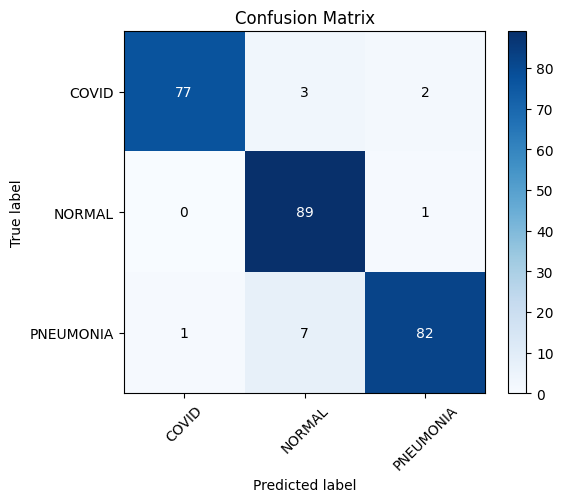

TEST acc         : 0.9465648854961832
TEST macro_f1    : 0.947147266313933
TEST weighted_f1 : 0.9466784805525265
TEST per_class   : [{'precision': 0.9871794871794872, 'recall': 0.9390243902439024, 'f1': 0.9625, 'support': 82}, {'precision': 0.898989898989899, 'recall': 0.9888888888888889, 'f1': 0.9417989417989419, 'support': 90}, {'precision': 0.9647058823529412, 'recall': 0.9111111111111111, 'f1': 0.9371428571428572, 'support': 90}]


{'acc': 0.9465648854961832,
 'micro_precision': 0.9465648854961832,
 'micro_recall': 0.9465648854961832,
 'micro_f1': 0.9465648854961832,
 'macro_precision': 0.9502917561741091,
 'macro_recall': 0.9463414634146341,
 'macro_f1': 0.947147266313933,
 'weighted_precision': 0.9491654132426472,
 'weighted_recall': 0.9465648854961832,
 'weighted_f1': 0.9466784805525265,
 'per_class': [{'precision': 0.9871794871794872,
   'recall': 0.9390243902439024,
   'f1': 0.9625,
   'support': 82},
  {'precision': 0.898989898989899,
   'recall': 0.9888888888888889,
   'f1': 0.9417989417989419,
   'support': 90},
  {'precision': 0.9647058823529412,
   'recall': 0.9111111111111111,
   'f1': 0.9371428571428572,
   'support': 90}],
 'confusion_matrix': tensor([[77,  3,  2],
         [ 0, 89,  1],
         [ 1,  7, 82]]),
 'logits': tensor([[-1.2293, -1.5634,  2.9863],
         [-1.2130,  2.5985, -1.3838],
         [ 0.7165, -1.8677,  1.4777],
         [ 2.9722, -1.2487, -1.5452],
         [-1.7741,  2.3272, -

In [ ]:
# load best model
ckpt = torch.load("/content/checkpoints/resnet50_best_tanaka.pt", map_location=device)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    model_resnet_enc.load_state_dict(ckpt["model_state"])
else:
    model_resnet_enc.load_state_dict(ckpt)

model_resnet_enc.to(device)
model_resnet_enc.eval()

# evaluate on TEST
test_result = evaluate_full(
    model_resnet_enc,
    test_enc_loader,
    device=device,
    num_classes=3
)

plot_confusion_matrix(
    test_result["confusion_matrix"],
    class_names=train_enc_ds_full.classes,
    normalize=False
)

print("TEST acc         :", test_result["acc"])
print("TEST macro_f1    :", test_result["macro_f1"])
print("TEST weighted_f1 :", test_result["weighted_f1"])
print("TEST per_class   :", test_result["per_class"])

test_result

# SKK

In [ ]:
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/imgs_skk' /content/data_skk

In [ ]:
import os

root = "/content/data_skk"
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

total = 0

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path):
        n = sum(
            1 for f in os.listdir(cls_path)
            if f.lower().endswith(valid_exts)
        )
        print(f"{cls}: {n}")
        total += n

print("Tổng:", total)

PNEUMONIA: 1800
COVID: 1626
NORMAL: 1802
Tổng: 5228


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np
import os

DATASET_ENCRYPTED_TRAIN = "/content/data_skk"
ENC_TRAIN = DATASET_ENCRYPTED_TRAIN

BATCH_SIZE = 64
NUM_WORKERS = 8
SEED = 42


full_ds = ImageFolder(ENC_TRAIN)
targets = np.array(full_ds.targets)
indices = np.arange(len(full_ds))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.1,
    stratify=targets,
    random_state=SEED
)

temp_targets = targets[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_targets,
    random_state=SEED
)

tf_stats = transforms.Compose([
    transforms.ToTensor(),
])

stats_ds_full = ImageFolder(ENC_TRAIN, transform=tf_stats)
train_stats_ds = Subset(stats_ds_full, train_idx)

mean_enc, std_enc = compute_mean_std(
    train_stats_ds,
    batch_size=BATCH_SIZE,
    max_samples=None
)

print("mean_enc:", mean_enc)
print("std_enc :", std_enc)

Compute mean/std:   0%|          | 0/74 [00:00<?, ?it/s]

mean_enc: [0.5010897517204285, 0.49760743975639343, 0.5001348853111267]
std_enc : [0.23952758312225342, 0.23951831459999084, 0.23953038454055786]


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np

# =========================
# 3) Transform
# =========================
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])


train_enc_ds_full = ImageFolder(ENC_TRAIN, transform=train_tf)
eval_enc_ds_full  = ImageFolder(ENC_TRAIN, transform=eval_tf)

train_enc_ds = Subset(train_enc_ds_full, train_idx)
val_enc_ds   = Subset(eval_enc_ds_full, val_idx)
test_enc_ds  = Subset(eval_enc_ds_full, test_idx)


train_enc_loader = DataLoader(
    train_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True
)

val_enc_loader = DataLoader(
    val_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

test_enc_loader = DataLoader(
    test_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

print("train:", len(train_enc_ds))
print("val  :", len(val_enc_ds))
print("test :", len(test_enc_ds))
print("classes:", train_enc_ds_full.classes)
print("class_to_idx:", train_enc_ds_full.class_to_idx)

# kiểm tra phân bố class từng split
train_targets = targets[train_idx]
val_targets   = targets[val_idx]
test_targets  = targets[test_idx]

print("train class counts:", np.bincount(train_targets))
print("val   class counts:", np.bincount(val_targets))
print("test  class counts:", np.bincount(test_targets))

train: 4705
val  : 261
test : 262
classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
train class counts: [1463 1622 1620]
val   class counts: [81 90 90]
test  class counts: [82 90 90]


In [ ]:
import math
device = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 50
LR = 3e-4

model_resnet_enc = resnet50(
    num_classes=3,
    pretrained=True,
    freeze_backbone=False
).to(device)

best_path, csv_path = fit(
    model_resnet_enc,
    train_loader=train_enc_loader,
    val_loader=val_enc_loader,
    mixup = False,
    device=device,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=1e-4,
    patience=10,
    csv_path="logs/resnet50_log_skk.csv",
    best_path="checkpoints/resnet50_best_skk.pt",
    num_classes=3,
    use_amp=True,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.5612 acc 0.8046 || val loss 0.4191 acc 0.8774 macroF1 0.8782 | lr 3.00e-04 save


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 02/50 | train loss 0.3755 acc 0.9135 || val loss 0.3165 acc 0.9502 macroF1 0.9505 | lr 2.99e-04 save


...

Epoch 19/50 | train loss 0.2031 acc 0.9857 || val loss 0.2903 acc 0.9502 macroF1 0.9512 | lr 2.05e-04


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 20/50 | train loss 0.1963 acc 0.9889 || val loss 0.2922 acc 0.9579 macroF1 0.9587 | lr 1.96e-04


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 21/50 | train loss 0.1896 acc 0.9912 || val loss 0.2998 acc 0.9387 macroF1 0.9393 | lr 1.87e-04
Early stopping at epoch 21 (best macroF1=0.9618)


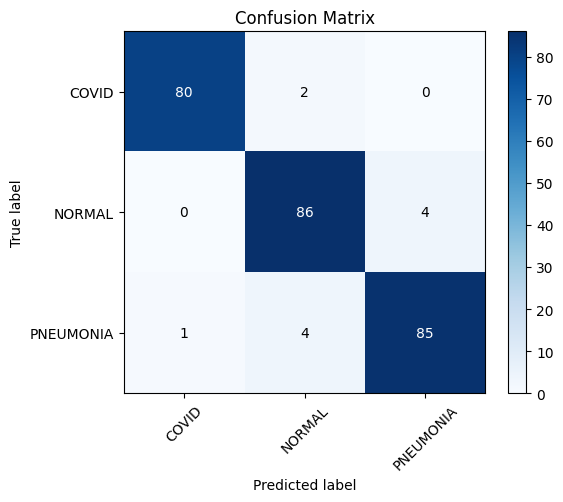

TEST acc         : 0.9580152671755725
TEST macro_f1    : 0.9587902358235154
TEST weighted_f1 : 0.9580939043364612
TEST per_class   : [{'precision': 0.9876543209876543, 'recall': 0.975609756097561, 'f1': 0.9815950920245398, 'support': 82}, {'precision': 0.9347826086956522, 'recall': 0.9555555555555556, 'f1': 0.945054945054945, 'support': 90}, {'precision': 0.9550561797752809, 'recall': 0.9444444444444444, 'f1': 0.9497206703910613, 'support': 90}]


{'acc': 0.9580152671755725,
 'micro_precision': 0.9580152671755725,
 'micro_recall': 0.9580152671755725,
 'micro_f1': 0.9580152671755725,
 'macro_precision': 0.9591643698195291,
 'macro_recall': 0.9585365853658536,
 'macro_f1': 0.9587902358235154,
 'weighted_precision': 0.9582944476464565,
 'weighted_recall': 0.9580152671755725,
 'weighted_f1': 0.9580939043364612,
 'per_class': [{'precision': 0.9876543209876543,
   'recall': 0.975609756097561,
   'f1': 0.9815950920245398,
   'support': 82},
  {'precision': 0.9347826086956522,
   'recall': 0.9555555555555556,
   'f1': 0.945054945054945,
   'support': 90},
  {'precision': 0.9550561797752809,
   'recall': 0.9444444444444444,
   'f1': 0.9497206703910613,
   'support': 90}],
 'confusion_matrix': tensor([[80,  2,  0],
         [ 0, 86,  4],
         [ 1,  4, 85]]),
 'logits': tensor([[-1.6760, -1.2572,  2.3994],
         [-1.1747,  2.6340, -1.1877],
         [ 2.2081, -1.4919, -1.2078],
         [ 2.2186, -1.2368, -1.4581],
         [-1.7279

In [ ]:
# load best model
ckpt = torch.load("/content/checkpoints/resnet50_best_skk.pt", map_location=device)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    model_resnet_enc.load_state_dict(ckpt["model_state"])
else:
    model_resnet_enc.load_state_dict(ckpt)

model_resnet_enc.to(device)
model_resnet_enc.eval()

# evaluate on TEST
test_result = evaluate_full(
    model_resnet_enc,
    test_enc_loader,
    device=device,
    num_classes=3
)

plot_confusion_matrix(
    test_result["confusion_matrix"],
    class_names=train_enc_ds_full.classes,
    normalize=False
)

print("TEST acc         :", test_result["acc"])
print("TEST macro_f1    :", test_result["macro_f1"])
print("TEST weighted_f1 :", test_result["weighted_f1"])
print("TEST per_class   :", test_result["per_class"])

test_result

# Huang

In [ ]:
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/imgs_huang2022' /content/data_huang2022

In [ ]:
import os

root = "/content/data_huang2022"
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

total = 0

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path):
        n = sum(
            1 for f in os.listdir(cls_path)
            if f.lower().endswith(valid_exts)
        )
        print(f"{cls}: {n}")
        total += n

print("Tổng:", total)

PNEUMONIA: 1800
COVID: 1626
NORMAL: 1802
Tổng: 5228


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np
import os

DATASET_ENCRYPTED_TRAIN = "/content/data_huang2022"
ENC_TRAIN = DATASET_ENCRYPTED_TRAIN

BATCH_SIZE = 64
NUM_WORKERS = 8
SEED = 42


full_ds = ImageFolder(ENC_TRAIN)
targets = np.array(full_ds.targets)
indices = np.arange(len(full_ds))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.1,
    stratify=targets,
    random_state=SEED
)

temp_targets = targets[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_targets,
    random_state=SEED
)

tf_stats = transforms.Compose([
    transforms.ToTensor(),
])

stats_ds_full = ImageFolder(ENC_TRAIN, transform=tf_stats)
train_stats_ds = Subset(stats_ds_full, train_idx)

mean_enc, std_enc = compute_mean_std(
    train_stats_ds,
    batch_size=BATCH_SIZE,
    max_samples=None
)

print("mean_enc:", mean_enc)
print("std_enc :", std_enc)

Compute mean/std:   0%|          | 0/74 [00:00<?, ?it/s]

mean_enc: [0.4999599754810333, 0.49995559453964233, 0.49994978308677673]
std_enc : [0.21332694590091705, 0.21334251761436462, 0.21331395208835602]


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np

# =========================
# 3) Transform
# =========================
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])


train_enc_ds_full = ImageFolder(ENC_TRAIN, transform=train_tf)
eval_enc_ds_full  = ImageFolder(ENC_TRAIN, transform=eval_tf)

train_enc_ds = Subset(train_enc_ds_full, train_idx)
val_enc_ds   = Subset(eval_enc_ds_full, val_idx)
test_enc_ds  = Subset(eval_enc_ds_full, test_idx)


train_enc_loader = DataLoader(
    train_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True
)

val_enc_loader = DataLoader(
    val_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

test_enc_loader = DataLoader(
    test_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

print("train:", len(train_enc_ds))
print("val  :", len(val_enc_ds))
print("test :", len(test_enc_ds))
print("classes:", train_enc_ds_full.classes)
print("class_to_idx:", train_enc_ds_full.class_to_idx)

# kiểm tra phân bố class từng split
train_targets = targets[train_idx]
val_targets   = targets[val_idx]
test_targets  = targets[test_idx]

print("train class counts:", np.bincount(train_targets))
print("val   class counts:", np.bincount(val_targets))
print("test  class counts:", np.bincount(test_targets))

train: 4705
val  : 261
test : 262
classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
train class counts: [1463 1622 1620]
val   class counts: [81 90 90]
test  class counts: [82 90 90]


In [ ]:
import math
device = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 50
LR = 3e-4

model_resnet_enc = resnet50(
    num_classes=3,
    pretrained=True,
    freeze_backbone=False
).to(device)

best_path, csv_path = fit(
    model_resnet_enc,
    train_loader=train_enc_loader,
    val_loader=val_enc_loader,
    mixup = False,
    device=device,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=1e-4,
    patience=10,
    csv_path="logs/resnet50_log_skk.csv",
    best_path="checkpoints/resnet50_best_skk.pt",
    num_classes=3,
    use_amp=True,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.4769 acc 0.8538 || val loss 0.3297 acc 0.9272 macroF1 0.9281 | lr 3.00e-04 save


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 02/50 | train loss 0.3360 acc 0.9262 || val loss 0.2723 acc 0.9732 macroF1 0.9732 | lr 2.99e-04 save


...

Epoch 15/50 | train loss 0.1877 acc 0.9955 || val loss 0.2128 acc 0.9808 macroF1 0.9810 | lr 2.38e-04


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 16/50 | train loss 0.1841 acc 0.9959 || val loss 0.2067 acc 0.9847 macroF1 0.9848 | lr 2.30e-04


Train:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 17/50 | train loss 0.1825 acc 0.9970 || val loss 0.2226 acc 0.9770 macroF1 0.9770 | lr 2.22e-04
Early stopping at epoch 17 (best macroF1=0.9850)


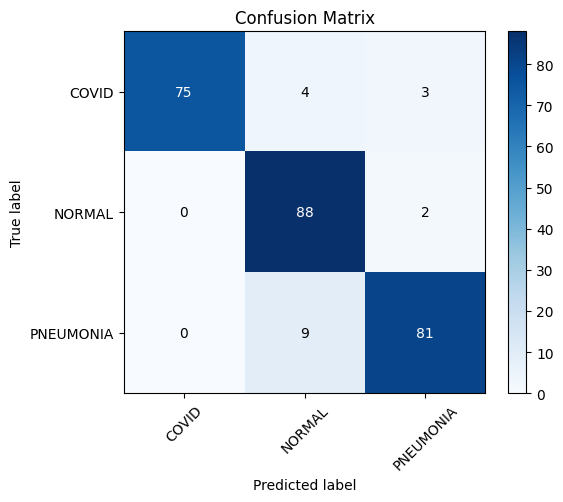

TEST acc         : 0.9312977099236641
TEST macro_f1    : 0.9324448422599289
TEST weighted_f1 : 0.9317434935430151
TEST per_class   : [{'precision': 1.0, 'recall': 0.9146341463414634, 'f1': 0.9554140127388536, 'support': 82}, {'precision': 0.8712871287128713, 'recall': 0.9777777777777777, 'f1': 0.9214659685863874, 'support': 90}, {'precision': 0.9418604651162791, 'recall': 0.9, 'f1': 0.9204545454545455, 'support': 90}]


{'acc': 0.9312977099236641,
 'micro_precision': 0.9312977099236641,
 'micro_recall': 0.9312977099236641,
 'micro_f1': 0.9312977099236641,
 'macro_precision': 0.9377158646097167,
 'macro_recall': 0.9308039747064137,
 'macro_f1': 0.9324448422599289,
 'weighted_precision': 0.9358140589489448,
 'weighted_recall': 0.9312977099236641,
 'weighted_f1': 0.9317434935430151,
 'per_class': [{'precision': 1.0,
   'recall': 0.9146341463414634,
   'f1': 0.9554140127388536,
   'support': 82},
  {'precision': 0.8712871287128713,
   'recall': 0.9777777777777777,
   'f1': 0.9214659685863874,
   'support': 90},
  {'precision': 0.9418604651162791,
   'recall': 0.9,
   'f1': 0.9204545454545455,
   'support': 90}],
 'confusion_matrix': tensor([[75,  4,  3],
         [ 0, 88,  2],
         [ 0,  9, 81]]),
 'logits': tensor([[-1.2535, -1.2654,  2.8133],
         [-1.9438,  2.2305,  0.4852],
         [ 1.2070, -1.6164,  0.8779],
         [ 2.8999, -0.8195, -1.4523],
         [-1.7596,  3.7085, -0.8387],
       

In [ ]:
# load best model
ckpt = torch.load("/content/checkpoints/resnet50_best_skk.pt", map_location=device)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    model_resnet_enc.load_state_dict(ckpt["model_state"])
else:
    model_resnet_enc.load_state_dict(ckpt)

model_resnet_enc.to(device)
model_resnet_enc.eval()

# evaluate on TEST
test_result = evaluate_full(
    model_resnet_enc,
    test_enc_loader,
    device=device,
    num_classes=3
)

plot_confusion_matrix(
    test_result["confusion_matrix"],
    class_names=train_enc_ds_full.classes,
    normalize=False
)

print("TEST acc         :", test_result["acc"])
print("TEST macro_f1    :", test_result["macro_f1"])
print("TEST weighted_f1 :", test_result["weighted_f1"])
print("TEST per_class   :", test_result["per_class"])

test_result

# Cross validation

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix


def save_confusion_matrix_to_file(cm, class_names, save_path, normalize=False, figsize=(6, 5), title="Confusion Matrix"):
    cm = cm.clone().float()

    if normalize:
        row_sums = cm.sum(dim=1, keepdim=True).clamp_min(1)
        cm = cm / row_sums

    num_classes = cm.shape[0]

    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()

    tick_marks = range(num_classes)
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max().item() / 2 if cm.numel() > 0 else 0.5

    for i in range(num_classes):
        for j in range(num_classes):
            value = cm[i, j].item()
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            plt.text(
                j, i, text,
                ha="center", va="center",
                color="white" if value > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()


def plot_cv_mean_curves(all_logs_df, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    agg = all_logs_df.groupby("epoch").agg({
        "train_loss": ["mean", "std"],
        "val_loss": ["mean", "std"],
        "val_acc": ["mean", "std"],
        "val_macro_f1": ["mean", "std"],
    })
    agg.columns = ["_".join(col) for col in agg.columns]
    agg = agg.reset_index()

    agg.to_csv(os.path.join(save_dir, "cv_mean_curves.csv"), index=False)

    # loss
    plt.figure(figsize=(7, 5))
    plt.plot(agg["epoch"], agg["train_loss_mean"], label="train_loss_mean")
    plt.fill_between(
        agg["epoch"],
        agg["train_loss_mean"] - agg["train_loss_std"].fillna(0),
        agg["train_loss_mean"] + agg["train_loss_std"].fillna(0),
        alpha=0.2
    )

    plt.plot(agg["epoch"], agg["val_loss_mean"], label="val_loss_mean")
    plt.fill_between(
        agg["epoch"],
        agg["val_loss_mean"] - agg["val_loss_std"].fillna(0),
        agg["val_loss_mean"] + agg["val_loss_std"].fillna(0),
        alpha=0.2
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Cross-validation Mean Loss Curves")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "cv_mean_loss.png"), dpi=200, bbox_inches="tight")
    plt.close()

    # metrics
    plt.figure(figsize=(7, 5))
    plt.plot(agg["epoch"], agg["val_acc_mean"], label="val_acc_mean")
    plt.fill_between(
        agg["epoch"],
        agg["val_acc_mean"] - agg["val_acc_std"].fillna(0),
        agg["val_acc_mean"] + agg["val_acc_std"].fillna(0),
        alpha=0.2
    )

    plt.plot(agg["epoch"], agg["val_macro_f1_mean"], label="val_macro_f1_mean")
    plt.fill_between(
        agg["epoch"],
        agg["val_macro_f1_mean"] - agg["val_macro_f1_std"].fillna(0),
        agg["val_macro_f1_mean"] + agg["val_macro_f1_std"].fillna(0),
        alpha=0.2
    )

    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Cross-validation Mean Validation Metrics")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "cv_mean_val_metrics.png"), dpi=200, bbox_inches="tight")
    plt.close()


def run_cross_validation(
    dataset_root,
    model_fn,
    compute_mean_std,
    num_classes=3,
    n_splits=5,
    batch_size=64,
    num_workers=8,
    epochs=50,
    lr=3e-4,
    weight_decay=1e-4,
    patience=10,
    device="cuda",
    use_amp=True,
    mixup=False,
    seed=42,
    save_root="cv_runs",
):
    """
    dataset_root: path ImageFolder
    model_fn: ví dụ lambda: resnet50(num_classes=3, pretrained=True, freeze_backbone=False)
    compute_mean_std: hàm bạn đã có
    """

    os.makedirs(save_root, exist_ok=True)

    base_ds = ImageFolder(dataset_root)
    targets = np.array(base_ds.targets)
    indices = np.arange(len(base_ds))
    class_names = base_ds.classes

    print("classes:", class_names)
    print("class_to_idx:", base_ds.class_to_idx)
    print("full counts:", np.bincount(targets))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    fold_metrics = []
    all_logs = []
    oof_rows = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(indices, targets), start=1):
        print("\n" + "=" * 90)
        print(f"FOLD {fold}/{n_splits}")
        print("=" * 90)

        fold_dir = os.path.join(save_root, f"fold_{fold}")
        os.makedirs(fold_dir, exist_ok=True)

        train_targets = targets[train_idx]
        val_targets = targets[val_idx]

        print("train size:", len(train_idx), "class counts:", np.bincount(train_targets))
        print("val   size:", len(val_idx), "class counts:", np.bincount(val_targets))

        # 1) compute mean/std ONLY on train fold
        stats_tf = transforms.Compose([
            transforms.ToTensor(),
        ])
        stats_ds_full = ImageFolder(dataset_root, transform=stats_tf)
        train_stats_ds = Subset(stats_ds_full, train_idx)

        mean_enc, std_enc = compute_mean_std(
            train_stats_ds,
            batch_size=batch_size,
            max_samples=None
        )

        print("mean_enc:", mean_enc)
        print("std_enc :", std_enc)

        with open(os.path.join(fold_dir, "fold_stats.json"), "w") as f:
            json.dump({
                "mean_enc": list(mean_enc),
                "std_enc": list(std_enc),
                "train_size": int(len(train_idx)),
                "val_size": int(len(val_idx)),
                "train_class_counts": np.bincount(train_targets).tolist(),
                "val_class_counts": np.bincount(val_targets).tolist(),
            }, f, indent=2)

        # 2) transforms
        train_tf = transforms.Compose([
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomRotation(3),
            transforms.ToTensor(),
            transforms.Normalize(mean_enc, std_enc),
        ])

        eval_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean_enc, std_enc),
        ])

        # 3) datasets
        train_ds_full = ImageFolder(dataset_root, transform=train_tf)
        eval_ds_full = ImageFolder(dataset_root, transform=eval_tf)

        train_ds = Subset(train_ds_full, train_idx)
        val_ds = Subset(eval_ds_full, val_idx)

        # 4) loaders
        train_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=True,
            persistent_workers=(num_workers > 0),
            drop_last=True
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True,
            persistent_workers=(num_workers > 0),
            drop_last=False
        )

        # 5) new model each fold
        model = model_fn().to(device)

        best_path = os.path.join(fold_dir, "best_restnet50_enc.pt")
        csv_path = os.path.join(fold_dir, "epoch_log_restnet50_enc.csv")

        fit(
            model,
            train_loader=train_loader,
            val_loader=val_loader,
            mixup=mixup,
            device=device,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            patience=patience,
            csv_path=csv_path,
            best_path=best_path,
            num_classes=num_classes,
            use_amp=use_amp,
        )

        # 6) load best model and evaluate on val fold
        ckpt = torch.load(best_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        model.eval()

        val_result = evaluate_full(model, val_loader, device=device, num_classes=num_classes)

        # save confusion matrix
        save_confusion_matrix_to_file(
            val_result["confusion_matrix"],
            class_names=class_names,
            save_path=os.path.join(fold_dir, "val_confusion_matrix.png"),
            normalize=False,
            title=f"Fold {fold} Confusion Matrix"
        )
        save_confusion_matrix_to_file(
            val_result["confusion_matrix"],
            class_names=class_names,
            save_path=os.path.join(fold_dir, "val_confusion_matrix_norm.png"),
            normalize=True,
            title=f"Fold {fold} Confusion Matrix (Normalized)"
        )

        # read epoch log
        fold_log_df = pd.read_csv(csv_path)
        fold_log_df["fold"] = fold
        all_logs.append(fold_log_df)

        # best epoch from csv
        best_rows = fold_log_df[fold_log_df["is_best"] == 1]
        best_epoch = int(best_rows.iloc[-1]["epoch"]) if len(best_rows) > 0 else int(fold_log_df.iloc[-1]["epoch"])

        fold_row = {
            "fold": fold,
            "best_epoch": best_epoch,
            "val_acc": val_result["acc"],
            "val_macro_precision": val_result["macro_precision"],
            "val_macro_recall": val_result["macro_recall"],
            "val_macro_f1": val_result["macro_f1"],
            "val_weighted_f1": val_result["weighted_f1"],
        }

        for c, stats in enumerate(val_result["per_class"]):
            fold_row[f"class_{c}_precision"] = stats["precision"]
            fold_row[f"class_{c}_recall"] = stats["recall"]
            fold_row[f"class_{c}_f1"] = stats["f1"]
            fold_row[f"class_{c}_support"] = stats["support"]

        fold_metrics.append(fold_row)

        # OOF rows
        y_true = val_result["y_true"].numpy()
        y_pred = val_result["logits"].argmax(dim=1).numpy()
        logits = val_result["logits"].numpy()

        for ds_idx, yt, yp, logit in zip(val_idx, y_true, y_pred, logits):
            row = {
                "fold": fold,
                "dataset_index": int(ds_idx),
                "y_true": int(yt),
                "y_pred": int(yp),
            }
            for c in range(num_classes):
                row[f"logit_class_{c}"] = float(logit[c])
            oof_rows.append(row)

    # ======================================================
    # aggregate results
    # ======================================================
    fold_metrics_df = pd.DataFrame(fold_metrics)
    fold_metrics_df.to_csv(os.path.join(save_root, "fold_metrics.csv"), index=False)

    summary_rows = []
    for col in ["val_acc", "val_macro_precision", "val_macro_recall", "val_macro_f1", "val_weighted_f1"]:
        summary_rows.append({
            "metric": col,
            "mean": fold_metrics_df[col].mean(),
            "std": fold_metrics_df[col].std(ddof=1),
            "min": fold_metrics_df[col].min(),
            "max": fold_metrics_df[col].max(),
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(os.path.join(save_root, "cv_summary.csv"), index=False)

    all_logs_df = pd.concat(all_logs, ignore_index=True)
    all_logs_df.to_csv(os.path.join(save_root, "all_epoch_logs.csv"), index=False)

    oof_df = pd.DataFrame(oof_rows).sort_values(["dataset_index"])
    oof_df.to_csv(os.path.join(save_root, "oof_predictions.csv"), index=False)

    # OOF confusion matrix
    oof_cm = confusion_matrix(
        oof_df["y_true"],
        oof_df["y_pred"],
        labels=list(range(num_classes))
    )
    oof_cm_t = torch.tensor(oof_cm)

    save_confusion_matrix_to_file(
        oof_cm_t,
        class_names=class_names,
        save_path=os.path.join(save_root, "oof_confusion_matrix.png"),
        normalize=False,
        title="OOF Confusion Matrix"
    )
    save_confusion_matrix_to_file(
        oof_cm_t,
        class_names=class_names,
        save_path=os.path.join(save_root, "oof_confusion_matrix_norm.png"),
        normalize=True,
        title="OOF Confusion Matrix (Normalized)"
    )

    plot_cv_mean_curves(all_logs_df, save_dir=os.path.join(save_root, "figures"))

    print("\n" + "=" * 90)
    print("CROSS-VALIDATION FINISHED")
    print("=" * 90)
    print(summary_df)

    return {
        "fold_metrics_df": fold_metrics_df,
        "summary_df": summary_df,
        "all_logs_df": all_logs_df,
        "oof_df": oof_df,
        "save_root": save_root,
    }

In [ ]:
cv_result = run_cross_validation(
    dataset_root=ENC_TRAIN,
    model_fn=lambda: resnet50(
        num_classes=3,
        pretrained=True,
        freeze_backbone=False
    ),
    compute_mean_std=compute_mean_std,
    num_classes=3,
    n_splits=5,
    batch_size=64,
    num_workers=8,
    epochs=50,
    lr=3e-4,
    weight_decay=1e-4,
    patience=10,
    device=device,
    use_amp=True,
    mixup=False,
    seed=42,
    save_root="cv_runs_resnet50"
)

classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
full counts: [1626 1802 1800]

FOLD 1/5
train size: 4182 class counts: [1300 1442 1440]
val   size: 1046 class counts: [326 360 360]
mean_enc: [0.12633903324604034, 0.12633682787418365, 0.12660057842731476]
std_enc : [0.19116565585136414, 0.19108717143535614, 0.19145183265209198]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.5086 acc 0.8413 || val loss 0.4436 acc 0.8767 macroF1 0.8765 | lr 3.00e-04 save


Train:   0%|          | 0/65 [00:00<?, ?it/s]

...

Epoch 45/50 | train loss 0.1696 acc 1.0000 || val loss 0.2550 acc 0.9675 macroF1 0.9681 | lr 7.34e-06


Train:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 46/50 | train loss 0.1702 acc 0.9998 || val loss 0.2569 acc 0.9684 macroF1 0.9689 | lr 4.71e-06


Train:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 47/50 | train loss 0.1695 acc 1.0000 || val loss 0.2598 acc 0.9665 macroF1 0.9670 | lr 2.66e-06
Early stopping at epoch 47 (best macroF1=0.9747)

CROSS-VALIDATION FINISHED
                metric      mean       std       min       max
0              val_acc  0.967102  0.006600  0.956979  0.974163
1  val_macro_precision  0.967739  0.006511  0.957606  0.974725
2     val_macro_recall  0.967841  0.006393  0.958044  0.974601
3         val_macro_f1  0.967722  0.006467  0.957788  0.974662
4      val_weighted_f1  0.967065  0.006620  0.956911  0.974174


In [ ]:
cv_result = run_cross_validation(
    dataset_root=DATASET_ORG_TRAIN,
    model_fn=lambda: resnet50(
        num_classes=3,
        pretrained=True,
        freeze_backbone=False
    ),
    compute_mean_std=compute_mean_std,
    num_classes=3,
    n_splits=5,
    batch_size=64,
    num_workers=8,
    epochs=50,
    lr=3e-4,
    weight_decay=1e-4,
    patience=10,
    device=device,
    use_amp=True,
    mixup=False,
    seed=42,
    save_root="cv_runs_resnet50_origin"
)

classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
full counts: [1626 1802 1800]

FOLD 1/5
train size: 4182 class counts: [1300 1442 1440]
val   size: 1046 class counts: [326 360 360]
mean_enc: [0.50168377161026, 0.5017650127410889, 0.5019317269325256]
std_enc : [0.2394152730703354, 0.23941490054130554, 0.2394552230834961]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.3079 acc 0.9440 || val loss 0.6176 acc 0.7667 macroF1 0.7455 | lr 3.00e-04 save


Train:   0%|          | 0/65 [00:00<?, ?it/s]

...

Epoch 24/50 | train loss 0.1716 acc 0.9998 || val loss 0.1945 acc 0.9885 macroF1 0.9887 | lr 1.59e-04


Train:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 25/50 | train loss 0.1707 acc 0.9998 || val loss 0.1941 acc 0.9904 macroF1 0.9906 | lr 1.50e-04


Train:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 26/50 | train loss 0.1705 acc 0.9995 || val loss 0.1935 acc 0.9885 macroF1 0.9887 | lr 1.41e-04
Early stopping at epoch 26 (best macroF1=0.9925)

CROSS-VALIDATION FINISHED
                metric      mean       std       min       max
0              val_acc  0.993688  0.000857  0.992344  0.994264
1  val_macro_precision  0.993863  0.000804  0.992544  0.994497
2     val_macro_recall  0.993830  0.000863  0.992493  0.994447
3         val_macro_f1  0.993824  0.000838  0.992498  0.994452
4      val_weighted_f1  0.993689  0.000853  0.992350  0.994264
